# Notebook 1 - Analyse du Marche YouTube Marocain
## Niveau 1 : Benchmark 26 Createurs

**Objectif :** Comprendre les tendances de consommation de contenu au Maroc
pour proposer une strategie editoriale a la chaine BIMO.

**Structure :**
1. Import et fusion des donnees
2. Nettoyage du dataset
3. Feature Engineering
4. Analyse exploratoire (EDA)
5. Analyse thematique
6. Analyse temporelle
7. Analyse par youtubeur (Top 3 themes)
8. Synthese et recommandations strategiques


## 0. Imports et Configuration

In [111]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import glob
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

print("Imports OK")


Imports OK


## 1. Import et Fusion des donnees

In [112]:
files = glob.glob("src/data*.csv")
df_list = []

for file in files:
    df = pd.read_csv(file, encoding="utf-8-sig")
    df_list.append(df)

df = pd.concat(df_list, ignore_index=True)
df.to_csv("df_benchmark.csv", index=False)

print("Fusion terminee !")
print("Nombre total de lignes :", df.shape[0])
print("Nombre total de colonnes :", df.shape[1])


Fusion terminee !
Nombre total de lignes : 9519
Nombre total de colonnes : 30


In [113]:
df.head(5)

,position,channelId,channelTitle,videoId,publishedAt,publishedAtSQL,videoTitle,videoDescription,tags,videoCategoryId,...,licensedContent,hasPaidProductPlacement,locationDescription,latitude,longitude,viewCount,likeCount,dislikeCount,favoriteCount,commentCount
0,1,UCEsNqbwMdVFWmh1Thq13B4A,abdellah zarouk,zgAe3cqZVCE,2026-04-15T17:35:32Z,2026-04-15 17:35:32,طوب 5 | غرائب الجامعات المغربية 🤣🤣,kick: https://kick.com/zaroukabdellah For busi...,NaN,23.0,...,1.0,NaN,NaN,NaN,NaN,227474.0,7115.0,NaN,0.0,508.0
1,2,UCEsNqbwMdVFWmh1Thq13B4A,abdellah zarouk,u6avr_4SEd4,2026-03-23T17:16:32Z,2026-03-23 17:16:32,طوب 5 | أغرب فتاوى مغربية 🤣🤣,يسلط عبد الله زروق الضوء على فتاوى دينية مغربي...,"mi na3ima,boudbana,COMEDY,ABDELLAH ZAROUK,zaro...",23.0,...,1.0,NaN,NaN,NaN,NaN,300246.0,9126.0,NaN,0.0,860.0
2,3,UCEsNqbwMdVFWmh1Thq13B4A,abdellah zarouk,BxeiTEQ_Og4,2026-02-25T21:20:38Z,2026-02-25 21:20:38,طوب 5 | غرائب رياضية 🤣🤣,قناتي الخاصة بالألعاب: https://www.youtube.com...,"mi na3ima,boudbana,COMEDY,ABDELLAH ZAROUK,zaro...",23.0,...,1.0,NaN,NaN,NaN,NaN,162332.0,5114.0,NaN,0.0,256.0
3,4,UCEsNqbwMdVFWmh1Thq13B4A,abdellah zarouk,RO9N2JgaOeg,2026-02-17T22:24:47Z,2026-02-17 22:24:47,طوب 5 | أغرب مقالب مغربية 🤣🤣,يستعرض عبد الله زروق تطور مقالب وسائل التواصل ...,"mi na3ima,boudbana,COMEDY,ABDELLAH ZAROUK,zaro...",23.0,...,1.0,NaN,NaN,NaN,NaN,397151.0,12224.0,NaN,0.0,606.0
4,5,UCEsNqbwMdVFWmh1Thq13B4A,abdellah zarouk,4IDvvncwJvU,2026-01-20T18:08:10Z,2026-01-20 18:08:10,باريس لا تستحق 🤣🤣,قناتي الخاصة بالألعاب: https://www.youtube.com...,"mi na3ima,boudbana,COMEDY,ABDELLAH ZAROUK,zaro...",23.0,...,1.0,NaN,NaN,NaN,NaN,98611.0,4427.0,NaN,0.0,243.0


In [114]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9519 entries, 0 to 9518
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   position                 9519 non-null   int64  
 1   channelId                9518 non-null   object 
 2   channelTitle             9518 non-null   object 
 3   videoId                  9519 non-null   object 
 4   publishedAt              9518 non-null   object 
 5   publishedAtSQL           9518 non-null   object 
 6   videoTitle               9518 non-null   object 
 7   videoDescription         8443 non-null   object 
 8   tags                     6607 non-null   object 
 9   videoCategoryId          9518 non-null   float64
 10  videoCategoryLabel       9518 non-null   object 
 11  topicCategories          6406 non-null   object 
 12  duration                 9518 non-null   object 
 13  durationSec              9519 non-null   int64  
 14  dimension               

In [115]:
df.columns

Index(['position', 'channelId', 'channelTitle', 'videoId', 'publishedAt',
       'publishedAtSQL', 'videoTitle', 'videoDescription', 'tags',
       'videoCategoryId', 'videoCategoryLabel', 'topicCategories', 'duration',
       'durationSec', 'dimension', 'definition', 'caption', 'defaultLanguage',
       'defaultLAudioLanguage', 'thumbnail_maxres', 'licensedContent',
       'hasPaidProductPlacement', 'locationDescription', 'latitude',
       'longitude', 'viewCount', 'likeCount', 'dislikeCount', 'favoriteCount',
       'commentCount'],
      dtype='object')

In [116]:
print(df['channelTitle'].unique())

['abdellah zarouk' ' Ahmed Sabiri 2.0 ' 'Amine Belghazi' 'B3A9Lii' 'BIMO'
 'Black Moussiba' nan 'Abdelkader Kharraz' 'Farouk Life'
 ' Nationale Bedarija2-ناشيونال بالدارجة ' 'Jamal Alpha - 2' 'Kawtar Bamo'
 'Khalid Lidlissi & Dala' 'la3zawi family Two' 'Lassakri - لعسكري '
 'Mambah Fit' 'milfaya' 'Misaha | مساحة' 'مول الشفنجة'
 'More Bilal No Filter' 'NADIAS' 'REDA EL WAHABI' 'SAFAA' 'Simo Sedraty'
 'Souky Stories' 'Taha Essou' 'Zizou Vlogs']


## 2. Nettoyage du dataset

### 2.1 Rapport des valeurs manquantes

In [117]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({'missing': missing, '%': missing_pct})
missing_report[missing_report['missing'] > 0].sort_values('%', ascending=False)


,missing,%
dislikeCount,9519,100.00
hasPaidProductPlacement,9499,99.79
locationDescription,9371,98.45
longitude,9371,98.45
latitude,9371,98.45
topicCategories,3113,32.70
tags,2912,30.59
videoDescription,1076,11.30
thumbnail_maxres,400,4.20
licensedContent,326,3.42


### 2.2 Exploration des colonnes specifiques

In [118]:
print(df[df['channelTitle'].isnull()])


      position channelId channelTitle      videoId publishedAt publishedAtSQL  \
1426       423       NaN          NaN  qiEbrhXLJqA         NaN            NaN   

     videoTitle videoDescription tags  videoCategoryId  ... licensedContent  \
1426        NaN              NaN  NaN              NaN  ...             NaN   

     hasPaidProductPlacement locationDescription  latitude longitude  \
1426                     NaN                 NaN       NaN       NaN   

     viewCount likeCount dislikeCount favoriteCount commentCount  
1426       NaN       NaN          NaN           NaN          NaN  

[1 rows x 30 columns]


In [119]:
print(df['topicCategories'].describe())
print(df['topicCategories'].unique())


count                      6406
unique                      187
top       Lifestyle_(sociology)
freq                       1839
Name: topicCategories, dtype: object
['Society' nan 'Tourism' 'Lifestyle_(sociology),Tourism'
 'Politics,Society' 'Entertainment,Film' 'Association_football' 'Politics'
 'Food,Lifestyle_(sociology)' 'Lifestyle_(sociology)' 'Entertainment'
 'Food' 'Music'
 'Action-adventure_game,Action_game,Role-playing_video_game,Video_game_culture'
 'Religion' 'Sport,Sports_game' 'Sports_game' 'Association_football,Sport'
 'Action-adventure_game,Action_game,Video_game_culture'
 'Action-adventure_game,Action_game,Role-playing_video_game'
 'Music_of_Asia' 'Association_football,Lifestyle_(sociology)'
 'Lifestyle_(sociology),Technology' 'Food,Lifestyle_(sociology),Tourism'
 'Hip_hop_music,Music' 'Hip_hop_music,Music,Television_program' 'Sport'
 'Hip_hop_music' 'Entertainment,Hip_hop_music'
 'Hobby,Lifestyle_(sociology)' 'Entertainment,Television_program'
 'Entertainment,Humour' '

In [120]:
print(df['videoCategoryLabel'].unique())


['Comedy' 'People & Blogs' 'Music' 'Entertainment' 'Science & Technology'
 'Sports' 'Gaming' 'Howto & Style' 'Education' nan 'Travel & Events'
 'News & Politics' 'Nonprofits & Activism' 'Film & Animation']


In [121]:
print(df['favoriteCount'].describe())


count    9518.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: favoriteCount, dtype: float64


In [122]:
print(df['licensedContent'].unique())
print(df['licensedContent'].describe())


[ 1. nan]
count    9193.0
mean        1.0
std         0.0
min         1.0
25%         1.0
50%         1.0
75%         1.0
max         1.0
Name: licensedContent, dtype: float64


### 2.3 Justification des suppressions de colonnes

- **favoriteCount** : variable toujours egale a 0 (fonctionnalite YouTube deprecie), n'apporte aucune information pour l'analyse.
- **dislikeCount** : 100% de valeurs manquantes, donnee non accessible via l'API YouTube depuis 2021.
- **hasPaidProductPlacement** : 99.8% de valeurs manquantes, variable inexploitable.
- **locationDescription / latitude / longitude** : plus de 98% de valeurs manquantes.
- **thumbnail_maxres** : URL image, non utilisee en analyse quantitative.
- **licensedContent** : 100% True, variance nulle, aucune info discriminante.
- **dimension** : 100% '2d', variance nulle.
- **publishedAtSQL** : doublon de publishedAt (meme info, format different).
- **position** : numero de position dans la playlist de scraping, pas une metrique video.
- **channelId** : cle technique redondante avec channelTitle.
- **videoCategoryId** : redondant avec videoCategoryLabel (version lisible).


### 2.4 Suppression des colonnes inutilisables

In [123]:
cols_to_drop = [
    'favoriteCount', 'dislikeCount', 'hasPaidProductPlacement',
    'locationDescription', 'latitude', 'longitude', 'thumbnail_maxres',
    'licensedContent', 'dimension', 'publishedAtSQL',
    'position', 'channelId', 'videoCategoryId'
]

df = df.drop(columns=cols_to_drop, errors='ignore')
print("Colonnes restantes :", len(df.columns))
print(df.columns.tolist())


Colonnes restantes : 17
['channelTitle', 'videoId', 'publishedAt', 'videoTitle', 'videoDescription', 'tags', 'videoCategoryLabel', 'topicCategories', 'duration', 'durationSec', 'definition', 'caption', 'defaultLanguage', 'defaultLAudioLanguage', 'viewCount', 'likeCount', 'commentCount']


### 2.5 Nettoyage des lignes

In [124]:
# Supprimer les lignes sans channelTitle
df = df.dropna(subset=['channelTitle'])

# Nettoyer les espaces dans channelTitle
df['channelTitle'] = df['channelTitle'].str.strip()

# Supprimer les doublons sur videoId
n_dupes = df.duplicated('videoId').sum()
df = df.drop_duplicates(subset=['videoId'])
print("Doublons supprimes :", n_dupes)

# Supprimer les videos avec 0 vues (non publiees ou privees)
n_zero_views = (df['viewCount'] == 0).sum()
df = df[df['viewCount'] > 0]
print("Videos a 0 vues supprimees :", n_zero_views)

# Supprimer les videos avec duree = 0 (Shorts mal parses)
n_zero_dur = (df['durationSec'] == 0).sum()
df = df[df['durationSec'] > 0]
print("Videos a 0 sec supprimees :", n_zero_dur)

# Filtre temporel : garder uniquement 2020 a aujourd'hui
df['publishedAt'] = pd.to_datetime(df['publishedAt'], utc=True)
n_before = len(df)
df = df[df['publishedAt'].dt.year >= 2020]
n_filtered = n_before - len(df)
print("Videos anterieures a 2020 supprimees :", n_filtered)

print()
print("Dataset final :", df.shape[0], "videos |", df['channelTitle'].nunique(), "createurs")
print("Periode couverte :", df['publishedAt'].dt.year.min(), "a", df['publishedAt'].dt.year.max())


Doublons supprimes : 0
Videos a 0 vues supprimees : 8
Videos a 0 sec supprimees : 1
Videos anterieures a 2020 supprimees : 858

Dataset final : 8651 videos | 26 createurs
Periode couverte : 2020 a 2026


In [125]:
df.tail(5)

,channelTitle,videoId,publishedAt,videoTitle,videoDescription,tags,videoCategoryLabel,topicCategories,duration,durationSec,definition,caption,defaultLanguage,defaultLAudioLanguage,viewCount,likeCount,commentCount
9513,Zizou Vlogs,_lt_Ss0Vs4k,2020-11-21 19:22:35+00:00,مشيت للقرية الساحرة 😍وخلقناها معا مريكانيات ال...,Aتابعوني على تطبيق YouNow كل يوم بث ⬇️ https:/...,"Bimo,Koulchi,Abdellah zarrouk,Jamal alpha,Zoz ...",People & Blogs,"Lifestyle_(sociology),Tourism",PT26M42S,1602,hd,False,ar,en,313982.0,9251.0,511.0
9514,Zizou Vlogs,3eQfAJMIwUQ,2020-11-13 17:30:19+00:00,مشيت لجزيرة النساء وخلقنا السعادة معا تيتيز ال...,تابعوني على تطبيق YouNow كل يوم بث ⬇️ https://...,"Zizou vlogs,Hamada chroukate,Fayssal vlog,Fays...",People & Blogs,"Lifestyle_(sociology),Tourism",PT21M24S,1284,hd,False,ar,en,396394.0,11596.0,668.0
9515,Zizou Vlogs,GbhCqxcNbxQ,2020-11-09 19:13:48+00:00,حياة الليل فلاس فيغاس ديال المكسيك 😱 | Mexico ...,Aتابعوني على الانستغرام FOLLOW ME ON INSTAGRAM...,"Hassan diae vlogs,Mourad Mzouri vlogs,Aymane s...",People & Blogs,"Lifestyle_(sociology),Tourism",PT22M13S,1333,hd,False,ar,en,284940.0,9214.0,638.0
9517,Zizou Vlogs,o9dYvTlsihE,2020-08-11 14:41:53+00:00,درت مشروع ديال الهندية فالمكسيك بزيرو درهم شوف...,MY INSTAGRAM : zizouvlogs هدا الانستغرام ديال ...,"hassan diae vlogs,taha essou,niba tbib,hamada ...",People & Blogs,"Hobby,Lifestyle_(sociology)",PT33M50S,2030,hd,False,ar,ar,624096.0,20901.0,2212.0
9518,Zizou Vlogs,iFhbXvOjogU,2020-07-06 16:59:44+00:00,لقيت شارع فالمكسيك سميتو المغرب سماه مكسيكي بس...,‏INSTAGRAM :: @ZIZOUVLOGS ‏My second channel o...,"koulchi,bimo,abdellah zerrouk,taha essou,lala ...",People & Blogs,"Hobby,Lifestyle_(sociology)",PT15M24S,924,hd,False,ar,ar,195777.0,9300.0,800.0


### 2.6 Verification finale

In [126]:
missing_final = df.isnull().sum()
missing_final_pct = (missing_final / len(df) * 100).round(2)
report = pd.DataFrame({'Manquantes': missing_final, '%': missing_final_pct})
display(report[report['Manquantes'] > 0].sort_values('%', ascending=False))
print("Nettoyage termine.")


,Manquantes,%
tags,2883,33.33
topicCategories,2862,33.08
videoDescription,1068,12.35
likeCount,23,0.27
commentCount,14,0.16


Nettoyage termine.


## 3. Feature Engineering

### 3.1 Features temporelles

In [127]:
# Extraction des composantes temporelles
df['publish_year']       = df['publishedAt'].dt.year
df['publish_month']      = df['publishedAt'].dt.month
df['publish_month_name'] = df['publishedAt'].dt.strftime('%b')
df['publish_day_of_week']= df['publishedAt'].dt.dayofweek   # 0 = Lundi
df['publish_day_name']   = df['publishedAt'].dt.strftime('%A')
df['publish_hour']       = df['publishedAt'].dt.hour

# Saison marocaine (hemisphere nord)
def get_saison(month):
    if month in [12, 1, 2]:   return 'Hiver'
    elif month in [3, 4, 5]:  return 'Printemps'
    elif month in [6, 7, 8]:  return 'Ete'
    else:                     return 'Automne'

df['saison'] = df['publish_month'].apply(get_saison)

# Flag Ramadan (approximation 2020-2026)
ramadan_periods = [
    ('2020-04-24', '2020-05-23'),
    ('2021-04-12', '2021-05-11'),
    ('2022-04-02', '2022-05-01'),
    ('2023-03-22', '2023-04-20'),
    ('2024-03-11', '2024-04-09'),
    ('2025-03-01', '2025-03-29'),
    ('2026-02-18', '2026-03-18'),
]
df['is_ramadan'] = False
for start, end in ramadan_periods:
    mask = (
        (df['publishedAt'] >= pd.Timestamp(start, tz='UTC')) &
        (df['publishedAt'] <= pd.Timestamp(end,   tz='UTC'))
    )
    df.loc[mask, 'is_ramadan'] = True

print("Features temporelles creees")
print(df[['publish_year', 'publish_month', 'publish_hour',
          'publish_day_name', 'saison', 'is_ramadan']].head(3))


Features temporelles creees
   publish_year  publish_month  publish_hour publish_day_name     saison  \
0          2026              4            17        Wednesday  Printemps   
1          2026              3            17           Monday  Printemps   
2          2026              2            21        Wednesday      Hiver   

   is_ramadan  
0       False  
1       False  
2        True  


### 3.2 Features d'engagement

In [128]:
# Taux d'engagement (likes + comments / views)
df['engagement_rate'] = (
    (df['likeCount'].fillna(0) + df['commentCount'].fillna(0)) / df['viewCount']
).round(4)

# Like rate et comment rate separes
df['like_rate']    = (df['likeCount'].fillna(0)    / df['viewCount']).round(4)
df['comment_rate'] = (df['commentCount'].fillna(0) / df['viewCount']).round(4)

# Categorie de performance basee sur les quartiles de viewCount
q33 = df['viewCount'].quantile(0.33)
q66 = df['viewCount'].quantile(0.66)

def perf_label(v):
    if v >= q66:   return 'Top'
    elif v >= q33: return 'Moyen'
    else:          return 'Faible'

df['performance_tier'] = df['viewCount'].apply(perf_label)

print("Features engagement creees")
print("Engagement rate moyen :", round(df['engagement_rate'].mean() * 100, 2), "%")
print("Seuils performance -> Faible: <", round(q33), "| Moyen: <", round(q66), "| Top: >", round(q66), "vues")


Features engagement creees
Engagement rate moyen : 5.06 %
Seuils performance -> Faible: < 288315 | Moyen: < 842786 | Top: > 842786 vues


### 3.3 Features de contenu

In [129]:
# Duree categorisee
def categorize_duration(sec):
    if sec < 60:     return 'Short (moins 1min)'
    elif sec < 300:  return 'Court (1-5min)'
    elif sec < 1200: return 'Moyen (5-20min)'
    else:            return 'Long (plus 20min)'

df['duration_category'] = df['durationSec'].apply(categorize_duration)

# Longueur du titre
df['title_word_count']   = df['videoTitle'].fillna('').apply(lambda x: len(x.split()))
df['title_char_count']   = df['videoTitle'].fillna('').apply(len)
df['title_has_number']   = df['videoTitle'].fillna('').str.contains(r'[0-9]', na=False)
df['title_has_question'] = df['videoTitle'].fillna('').str.contains(r'[?]', na=False)

# Langue simplifiee
def map_lang(lang):
    if lang == 'ar':  return 'Arabe'
    elif lang == 'fr': return 'Francais'
    elif lang == 'en': return 'Anglais'
    else:             return 'Autre'

df['langue'] = df['defaultLanguage'].apply(map_lang)

# Tags count
df['tags_count'] = df['tags'].fillna('').apply(
    lambda x: len(x.split(',')) if x else 0
)

print("Features contenu creees")
print(df[['duration_category', 'title_word_count',
          'title_has_number', 'langue', 'tags_count']].head(3))


Features contenu creees
   duration_category  title_word_count  title_has_number langue  tags_count
0  Long (plus 20min)                 7              True  Arabe           0
1    Moyen (5-20min)                 7              True  Arabe          53
2  Long (plus 20min)                 6              True  Arabe          53


### 3.4 Classification thematique

In [ ]:
# Attribution basee sur le positionnement editorial reel de chaque createur
# Le theme_principal est le theme dominant, themes_secondaires liste les themes supplementaires

THEME_PRINCIPAL = {
    'Farouk Life'                           : 'news_reportage',
    'Simo Sedraty'                          : 'concept_format',
    'REDA EL WAHABI'                        : 'concept_format',
    'Jamal Alpha - 2'                       : 'reactions',
    'Souky Stories'                         : 'storytelling',
    'Mambah Fit'                            : 'concept_format',
    'Taha Essou'                            : 'vlog',
    'BIMO'                                  : 'storytelling',
    'Kawtar Bamo'                           : 'concept_format',
    'milfaya'                               : 'podcast',
    'More Bilal No Filter'                  : 'podcast',
    'SAFAA'                                 : 'storytelling',
    'مول الشفنجة'                           : 'vlog',
    'Lassakri - لعسكري'                    : 'storytelling',
    'Ahmed Sabiri 2.0'                      : 'reactions',
    'B3A9Lii'                               : 'reactions',
    'Misaha | مساحة'                        : 'news_reportage',
    'Amine Belghazi'                        : 'concept_format',
    'Zizou Vlogs'                           : 'vlog',
    'Abdelkader Kharraz'                    : 'storytelling',
    'Khalid Lidlissi & Dala'               : 'comedie',
    'abdellah zarouk'                       : 'reactions',
    'Black Moussiba'                        : 'reactions',
    'Nationale Bedarija2-ناشيونال بالدارجة': 'reactions',
    'la3zawi family Two'                    : 'famille_quotidien',
    'NADIAS'                                : 'storytelling',
}

THEMES_SECONDAIRES = {
    'Farouk Life'                           : ['storytelling', 'podcast'],
    'Simo Sedraty'                          : ['vlog', 'comedie'],
    'REDA EL WAHABI'                        : ['podcast', 'famille_quotidien', 'vlog'],
    'Jamal Alpha - 2'                       : ['comedie'],
    'Souky Stories'                         : [],
    'Mambah Fit'                            : ['podcast', 'howto_lifestyle'],
    'Taha Essou'                            : ['concept_format', 'podcast'],
    'BIMO'                                  : ['concept_format', 'reactions', 'comedie'],
    'Kawtar Bamo'                           : ['podcast', 'comedie', 'vlog'],
    'milfaya'                               : ['vlog'],
    'More Bilal No Filter'                  : ['comedie', 'reactions', 'vlog'],
    'SAFAA'                                 : [],
    'مول الشفنجة'                           : ['reactions', 'comedie', 'famille_quotidien'],
    'Lassakri - لعسكري'                    : [],
    'Ahmed Sabiri 2.0'                      : ['comedie', 'vlog'],
    'B3A9Lii'                               : ['comedie'],
    'Misaha | مساحة'                        : ['storytelling'],
    'Amine Belghazi'                        : ['comedie'],
    'Zizou Vlogs'                           : [],
    'Abdelkader Kharraz'                    : [],
    'Khalid Lidlissi & Dala'               : ['famille_quotidien'],
    'abdellah zarouk'                       : ['comedie'],
    'Black Moussiba'                        : ['comedie', 'podcast'],
    'Nationale Bedarija2-ناشيونال بالدارجة': ['comedie'],
    'la3zawi family Two'                    : [],
    'NADIAS'                                : [],
}

df['theme'] = df['channelTitle'].map(THEME_PRINCIPAL)
df['themes_secondaires'] = df['channelTitle'].map(
    lambda x: ', '.join(THEMES_SECONDAIRES.get(x, [])) if THEMES_SECONDAIRES.get(x) else 'aucun'
)

unmapped = df[df['theme'].isna()]['channelTitle'].unique()
if len(unmapped) > 0:
    print("Chaines non mappees :", unmapped)
else:
    print("Toutes les chaines ont un theme assigne")

print()
print("Distribution thematique principale :")
print(df['theme'].value_counts().to_string())


Toutes les chaines ont un theme assigne

Distribution thematique principale :
theme
comedie              2388
storytelling         1957
famille_quotidien    1741
news_reportage       1281
concept_format        815
vlog                  417
podcast                52


### 3.5 Export du dataset enrichi

In [131]:
df.to_csv("df_benchmark_clean.csv", index=False)
print("Dataset enrichi sauvegarde -> df_benchmark_clean.csv")
print("Shape finale :", df.shape[0], "videos x", df.shape[1], "colonnes")


Dataset enrichi sauvegarde -> df_benchmark_clean.csv
Shape finale : 8651 videos x 38 colonnes


## 4. Analyse Exploratoire (EDA)

### 4.1 Statistiques descriptives

In [132]:
df[['viewCount', 'likeCount', 'commentCount',
    'durationSec', 'engagement_rate']].describe().round(2)


,viewCount,likeCount,commentCount,durationSec,engagement_rate
count,8651.00,8628.00,8637.00,8651.00,8651.00
mean,901576.58,32890.06,1546.90,1099.90,0.05
std,1254821.77,37415.64,2516.21,737.49,0.03
min,1525.00,46.00,0.00,3.00,0.00
25%,216243.00,9310.00,384.00,594.00,0.03
50%,478807.00,22518.00,877.00,1004.00,0.04
75%,1117031.50,42836.25,1794.00,1514.50,0.06
max,19142924.00,593950.00,60975.00,3587.00,0.30


### 4.2 Distribution des vues (echelle log)

In [133]:
df['viewCount']

0       227474.0
1       300246.0
2       162332.0
3       397151.0
4        98611.0
          ...   
9513    313982.0
9514    396394.0
9515    284940.0
9517    624096.0
9518    195777.0
Name: viewCount, Length: 8651, dtype: float64

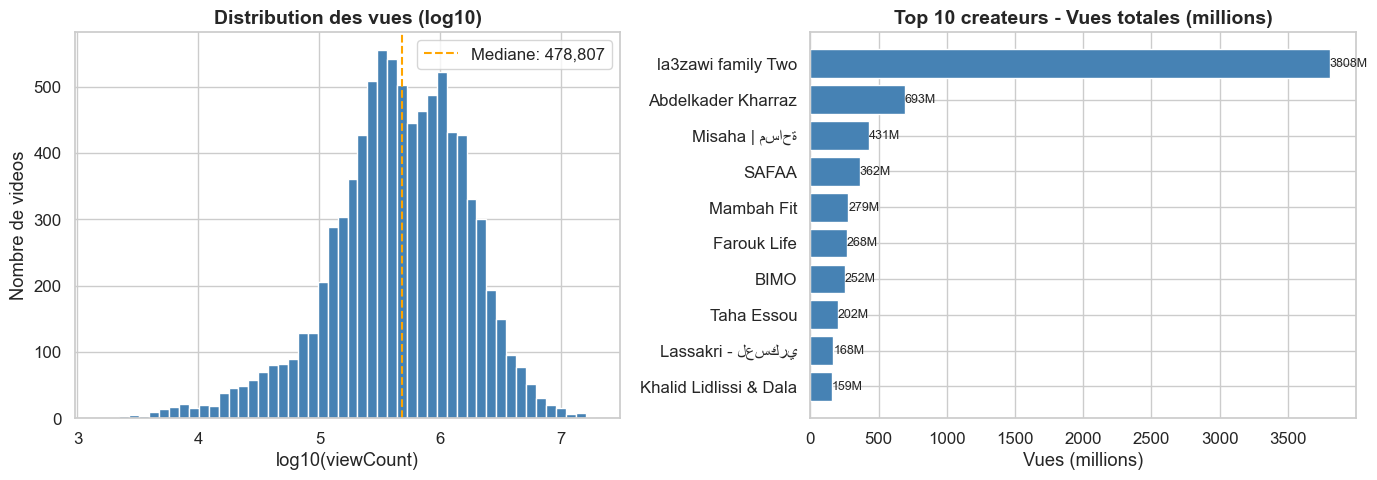

In [134]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution globale
axes[0].hist(np.log10(df['viewCount'] + 1), bins=50,
             color='steelblue', edgecolor='white')
axes[0].set_title("Distribution des vues (log10)")
axes[0].set_xlabel("log10(viewCount)")
axes[0].set_ylabel("Nombre de videos")
axes[0].axvline(
    np.log10(df['viewCount'].median()),
    color='orange', linestyle='--',
    label="Mediane: {:,.0f}".format(df['viewCount'].median())
)
axes[0].legend()

# Top 10 createurs par vues totales
top_channels = (
    df.groupby('channelTitle')['viewCount']
    .sum()
    .sort_values(ascending=True)
    .tail(10)
)
axes[1].barh(top_channels.index, top_channels.values / 1e6, color='steelblue')
axes[1].set_title("Top 10 createurs - Vues totales (millions)")
axes[1].set_xlabel("Vues (millions)")
for i, v in enumerate(top_channels.values):
    axes[1].text(v / 1e6 + 0.2, i, "{:.0f}M".format(v / 1e6),
                 va='center', fontsize=9)

plt.tight_layout()
plt.show()


### 4.3 Taux d'engagement par createur

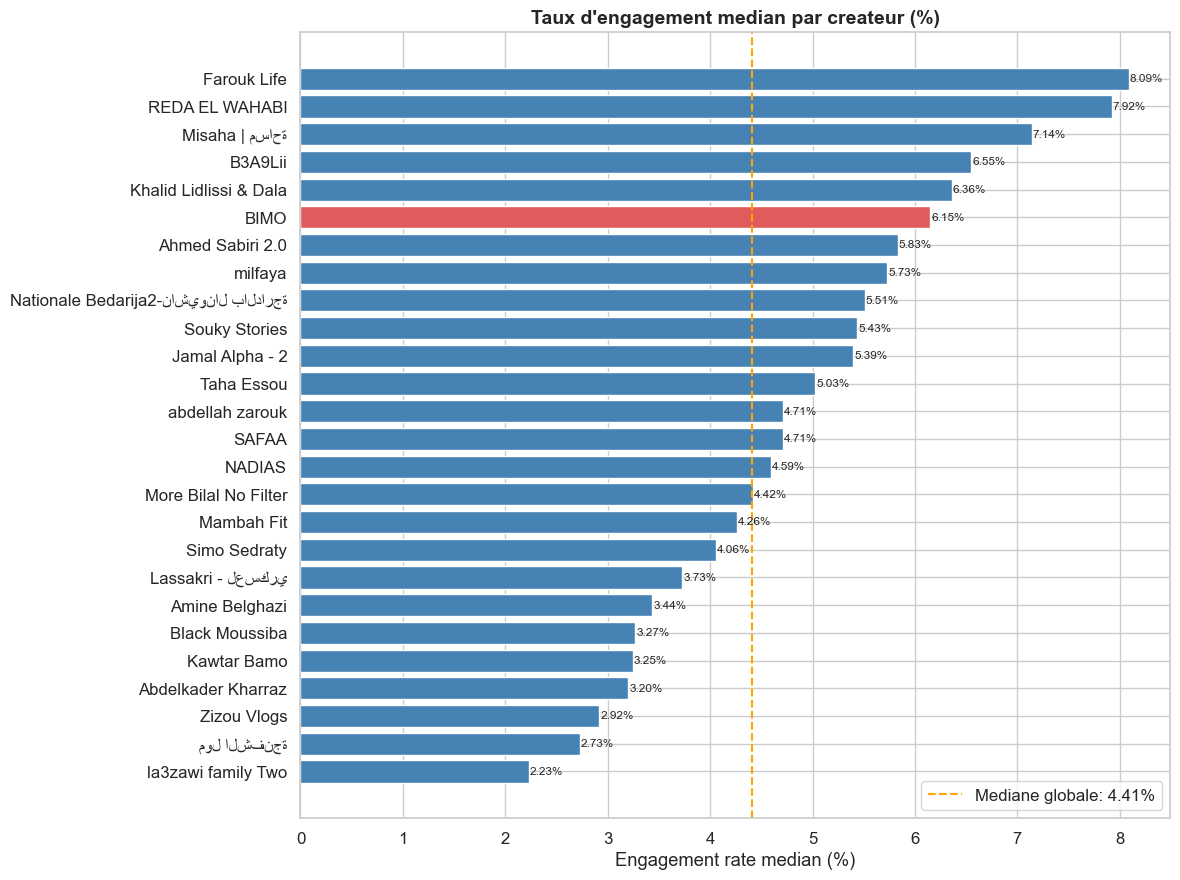

In [135]:
eng_by_channel = (
    df.groupby('channelTitle')['engagement_rate']
    .median()
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(12, 9))
colors = ['#e05c5c' if c == 'BIMO' else 'steelblue' for c in eng_by_channel.index]
bars = ax.barh(eng_by_channel.index, eng_by_channel.values * 100, color=colors)

ax.set_title("Taux d'engagement median par createur (%)")
ax.set_xlabel("Engagement rate median (%)")
ax.axvline(
    df['engagement_rate'].median() * 100,
    color='orange', linestyle='--',
    label="Mediane globale: {:.2f}%".format(df['engagement_rate'].median() * 100)
)
ax.legend()
for bar, val in zip(bars, eng_by_channel.values):
    ax.text(val * 100 + 0.01, bar.get_y() + bar.get_height() / 2,
            "{:.2f}%".format(val * 100), va='center', fontsize=8.5)

plt.tight_layout()
plt.show()


### 4.4 Duree optimale vs Performance

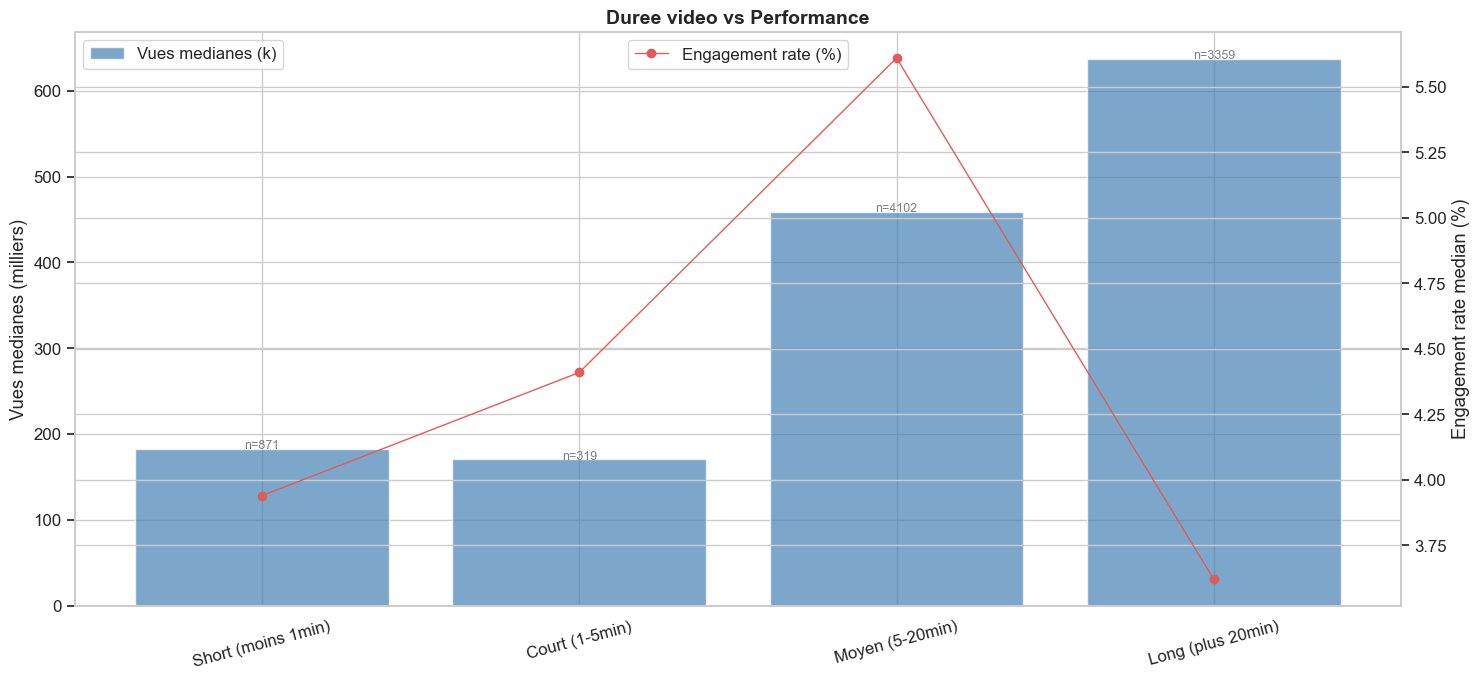

In [136]:
order_dur = ['Short (moins 1min)', 'Court (1-5min)', 'Moyen (5-20min)', 'Long (plus 20min)']

duration_perf = (
    df.groupby('duration_category')
    .agg(
        vues_medianes=('viewCount', 'median'),
        engagement_median=('engagement_rate', 'median'),
        nb_videos=('videoId', 'count')
    )
    .reset_index()
)
duration_perf['duration_category'] = pd.Categorical(
    duration_perf['duration_category'], categories=order_dur, ordered=True
)
duration_perf = duration_perf.sort_values('duration_category')

fig, ax1 = plt.subplots(figsize=(15, 7))
ax2 = ax1.twinx()

x = range(len(duration_perf))
ax1.bar(x, duration_perf['vues_medianes'] / 1e3,
        color='steelblue', alpha=0.7, label='Vues medianes (k)')
ax2.plot(x, duration_perf['engagement_median'] * 100,
         'o-', color='#e05c5c', lw=1, label='Engagement rate (%)')

ax1.set_xticks(x)
ax1.set_xticklabels(duration_perf['duration_category'], rotation=15)
ax1.set_ylabel("Vues medianes (milliers)")
ax2.set_ylabel("Engagement rate median (%)")
ax1.set_title("Duree video vs Performance")
ax1.legend(loc='upper left')
ax2.legend(loc='upper center')

for i, row in duration_perf.iterrows():
    pos = list(duration_perf.index).index(i)
    ax1.text(pos, row['vues_medianes'] / 1e3 + 0.3,
             "n={}".format(int(row['nb_videos'])),
             ha='center', fontsize=9, color='gray')

plt.tight_layout()
plt.show()


### 4.5 Matrice de correlation

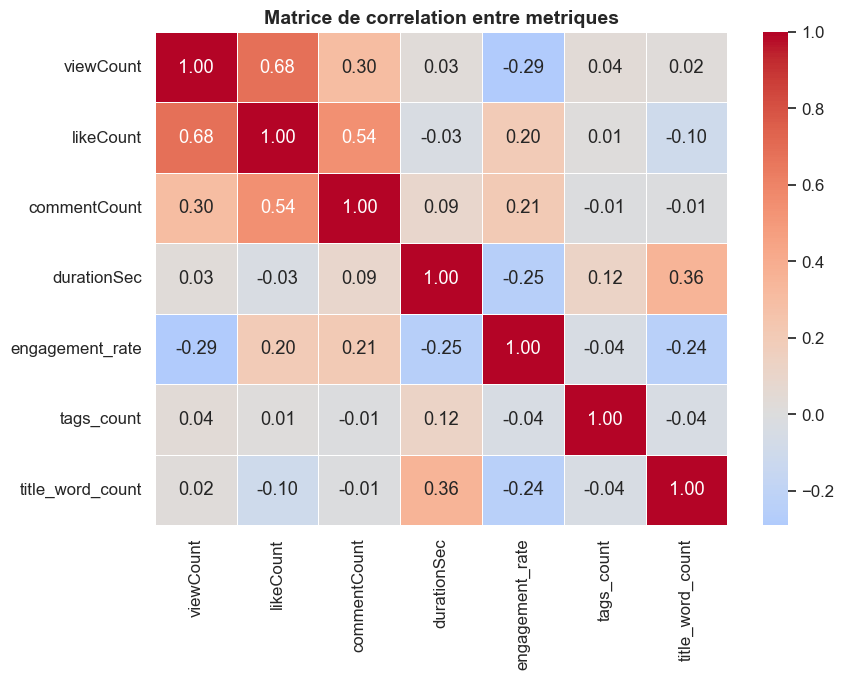

In [137]:
corr_cols = ['viewCount', 'likeCount', 'commentCount',
             'durationSec', 'engagement_rate', 'tags_count', 'title_word_count']
corr_matrix = df[corr_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5)
ax.set_title("Matrice de correlation entre metriques")
plt.tight_layout()
plt.show()


## 5. Analyse Thematique

### 5.1 Performance par theme principal

In [138]:
theme_stats = (
    df.groupby('theme')
    .agg(
        nb_videos=('videoId', 'count'),
        nb_chaines=('channelTitle', 'nunique'),
        vues_medianes=('viewCount', 'median'),
        vues_moyennes=('viewCount', 'mean'),
        engagement_median=('engagement_rate', 'median'),
        duree_mediane_sec=('durationSec', 'median')
    )
    .round(2)
    .sort_values('vues_medianes', ascending=False)
)

theme_stats['duree_mediane_min'] = (theme_stats['duree_mediane_sec'] / 60).round(1)
theme_stats = theme_stats.drop('duree_mediane_sec', axis=1)
theme_stats.columns = [
    'Nb videos', 'Nb chaines', 'Vues medianes',
    'Vues moyennes', 'Engagement median', 'Duree mediane (min)'
]
display(theme_stats)


,Nb videos,Nb chaines,Vues medianes,Vues moyennes,Engagement median,Duree mediane (min)
theme,,,,,,
famille_quotidien,1741,1,1672441.0,2187356.68,0.02,18.6
storytelling,1957,6,677934.0,826279.55,0.04,27.8
vlog,417,2,435593.0,658380.52,0.04,15.0
news_reportage,1281,2,383462.0,545775.75,0.08,9.6
podcast,52,1,329848.0,365800.75,0.06,17.8
comedie,2388,10,261515.0,368839.26,0.05,17.3
concept_format,815,4,155785.0,614513.74,0.04,0.8


### 5.2 Carte de chaleur - Theme x Duree

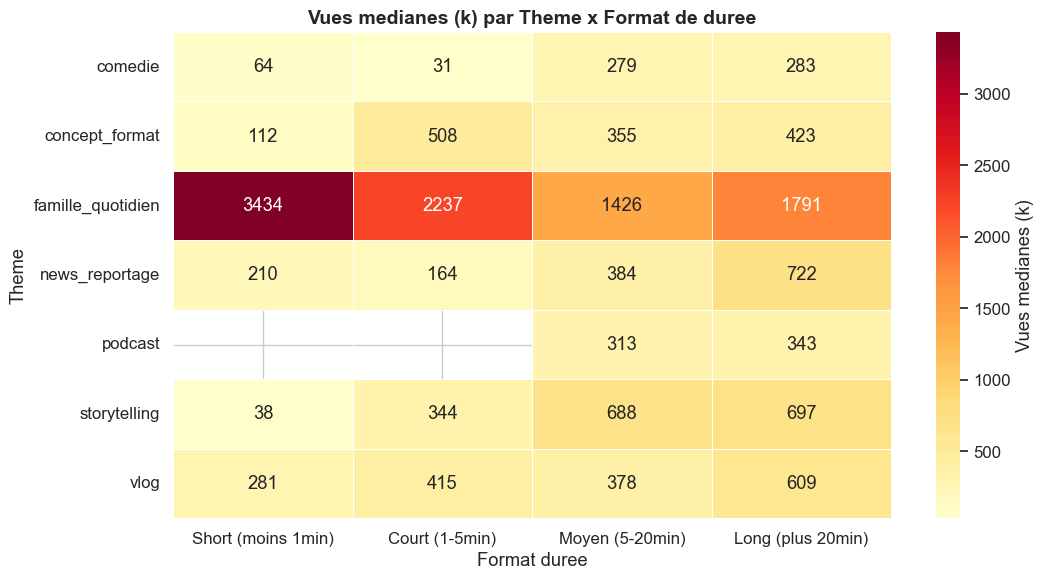

In [139]:
order_dur = ['Short (moins 1min)', 'Court (1-5min)', 'Moyen (5-20min)', 'Long (plus 20min)']
pivot_theme_dur = df.pivot_table(
    values='viewCount', index='theme',
    columns='duration_category', aggfunc='median'
)
pivot_theme_dur = pivot_theme_dur.reindex(
    columns=[c for c in order_dur if c in pivot_theme_dur.columns]
)

fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(pivot_theme_dur / 1e3, annot=True, fmt='.0f',
            cmap='YlOrRd', ax=ax, linewidths=0.5,
            cbar_kws={'label': 'Vues medianes (k)'})
ax.set_title("Vues medianes (k) par Theme x Format de duree")
ax.set_xlabel("Format duree")
ax.set_ylabel("Theme")
plt.tight_layout()
plt.show()


### 5.3 Comparaison BIMO vs benchmark

In [140]:
def compute_stats(data):
    return pd.Series({
        'vues_medianes': data['viewCount'].median(),
        'engagement_median': data['engagement_rate'].median(),
        'duree_mediane': data['durationSec'].median() / 60
    })

bimo_stats = compute_stats(df[df['channelTitle'] == 'BIMO'])
concept_stats = compute_stats(df[df['theme'] == 'concept_format'])
global_stats = compute_stats(df)

comparison = pd.DataFrame(
    [bimo_stats, concept_stats, global_stats],
    index=['BIMO', 'Concept Format (moy)', 'Global benchmark']
).round(2)

comparison.columns = ['Vues medianes', 'Engagement median', 'Duree mediane (min)']

display(comparison)

,Vues medianes,Engagement median,Duree mediane (min)
BIMO,801193.5,0.06,11.02
Concept Format (moy),155785.0,0.04,0.82
Global benchmark,478807.0,0.04,16.73


### 5.4 Vues medianes par theme (visualisation)

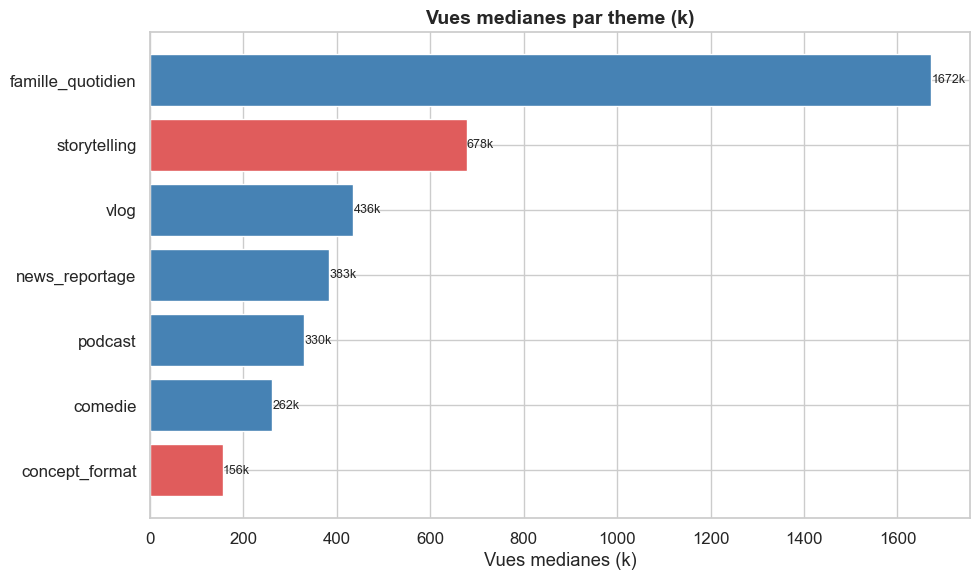

In [141]:
theme_views = (
    df.groupby('theme')['viewCount']
    .median()
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 6))
colors_t = ['#e05c5c' if t in ['storytelling', 'concept_format'] else 'steelblue'
            for t in theme_views.index]
bars = ax.barh(theme_views.index, theme_views.values / 1e3, color=colors_t)
ax.set_title("Vues medianes par theme (k)")
ax.set_xlabel("Vues medianes (k)")
for bar, val in zip(bars, theme_views.values):
    ax.text(val / 1e3 + 0.5, bar.get_y() + bar.get_height() / 2,
            "{:.0f}k".format(val / 1e3), va='center', fontsize=9)
plt.tight_layout()
plt.show()


## 6. Analyse Temporelle - Quand poster ?

### 6.1 Heatmap Jour x Heure (vues medianes)

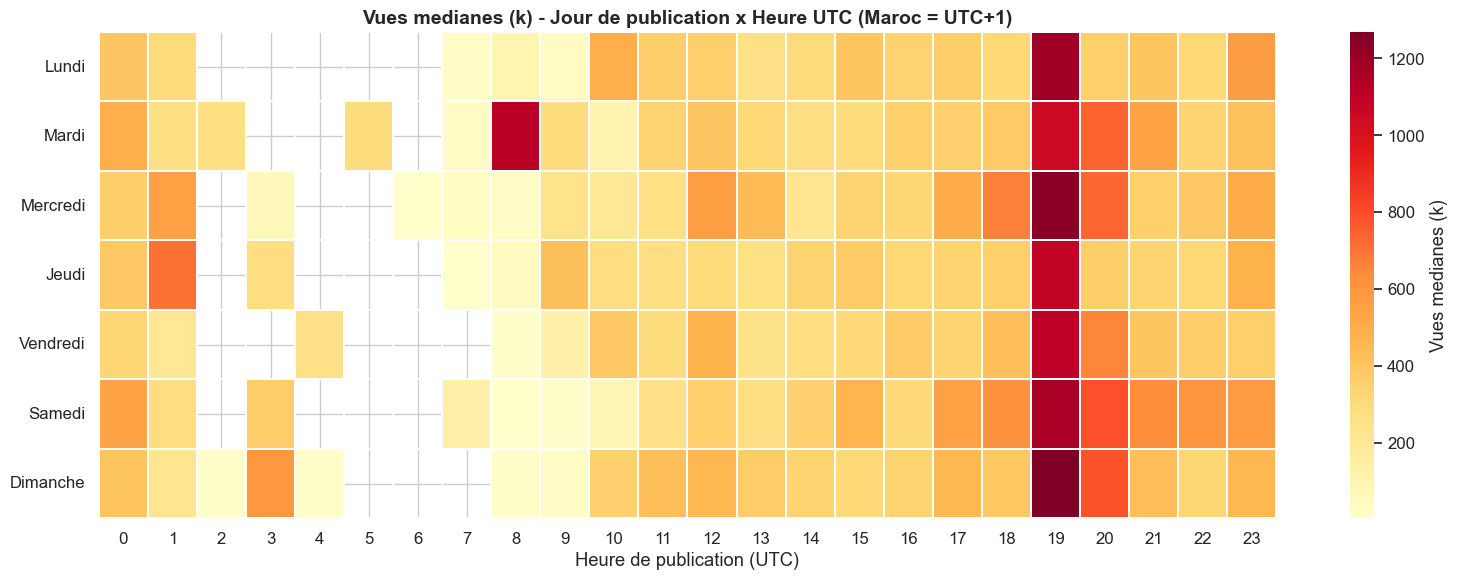

In [142]:
pivot_time = df.pivot_table(
    values='viewCount', index='publish_day_of_week',
    columns='publish_hour', aggfunc='median'
)

day_labels = ['Lundi', 'Mardi', 'Mercredi', 'Jeudi', 'Vendredi', 'Samedi', 'Dimanche']
pivot_time.index = [day_labels[i] for i in pivot_time.index if i < 7]

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(pivot_time / 1e3, cmap='YlOrRd', ax=ax, linewidths=0.3,
            cbar_kws={'label': 'Vues medianes (k)'}, annot=False)
ax.set_title("Vues medianes (k) - Jour de publication x Heure UTC (Maroc = UTC+1)")
ax.set_xlabel("Heure de publication (UTC)")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


### 6.2 Meilleur jour de publication

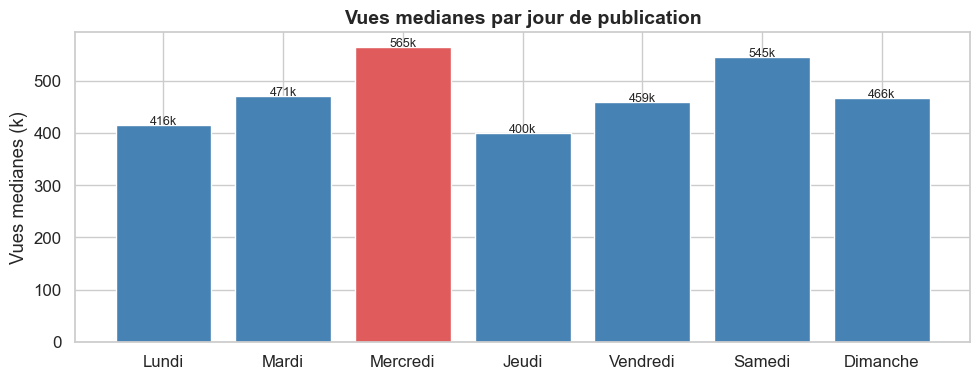

In [143]:
day_map = {0:'Lundi', 1:'Mardi', 2:'Mercredi', 3:'Jeudi',
           4:'Vendredi', 5:'Samedi', 6:'Dimanche'}
day_order = ['Lundi', 'Mardi', 'Mercredi', 'Jeudi', 'Vendredi', 'Samedi', 'Dimanche']

df['day_name_fr'] = df['publish_day_of_week'].map(day_map)
day_perf = df.groupby('day_name_fr')['viewCount'].median().reindex(day_order)

fig, ax = plt.subplots(figsize=(10, 4))
colors_day = ['#e05c5c' if v == day_perf.max() else 'steelblue'
              for v in day_perf.values]
bars = ax.bar(day_perf.index, day_perf.values / 1e3, color=colors_day)
ax.set_title("Vues medianes par jour de publication")
ax.set_ylabel("Vues medianes (k)")
for bar, val in zip(bars, day_perf.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            "{:.0f}k".format(val / 1e3), ha='center', fontsize=9)
plt.tight_layout()
plt.show()


### 6.3 Meilleure heure de publication

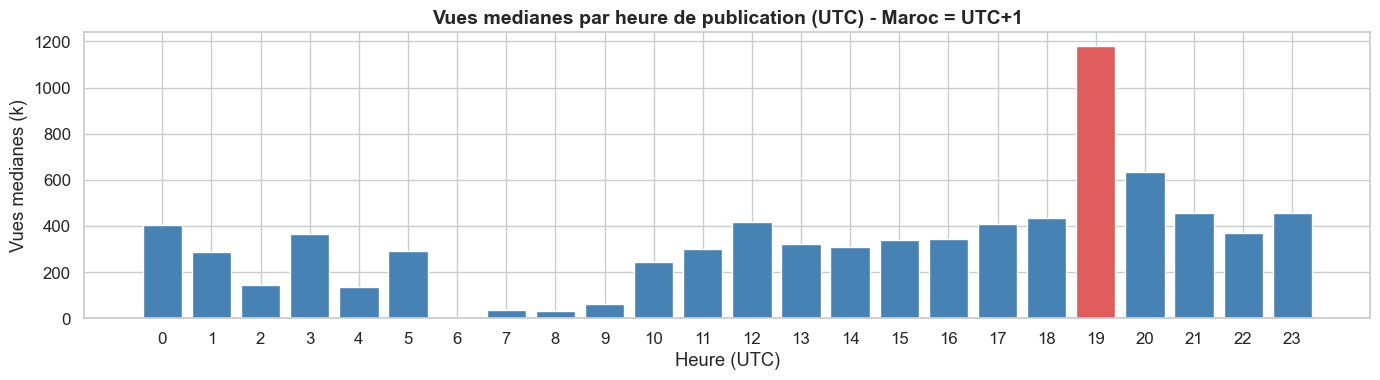

Meilleure heure UTC : 19 h -> Heure Maroc : 20 h


In [144]:
hour_perf = df.groupby('publish_hour')['viewCount'].median()

fig, ax = plt.subplots(figsize=(14, 4))
colors_h = ['#e05c5c' if v == hour_perf.max() else 'steelblue'
            for v in hour_perf.values]
bars = ax.bar(hour_perf.index, hour_perf.values / 1e3, color=colors_h)
ax.set_title("Vues medianes par heure de publication (UTC) - Maroc = UTC+1")
ax.set_xlabel("Heure (UTC)")
ax.set_ylabel("Vues medianes (k)")
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.show()

best_utc = hour_perf.idxmax()
print("Meilleure heure UTC :", best_utc, "h -> Heure Maroc :", (best_utc + 1) % 24, "h")


### 6.4 Effet Ramadan

,Vues medianes,Engagement median,Nb videos
Hors Ramadan,478763.0,0.04,7703
Ramadan,481341.5,0.04,948


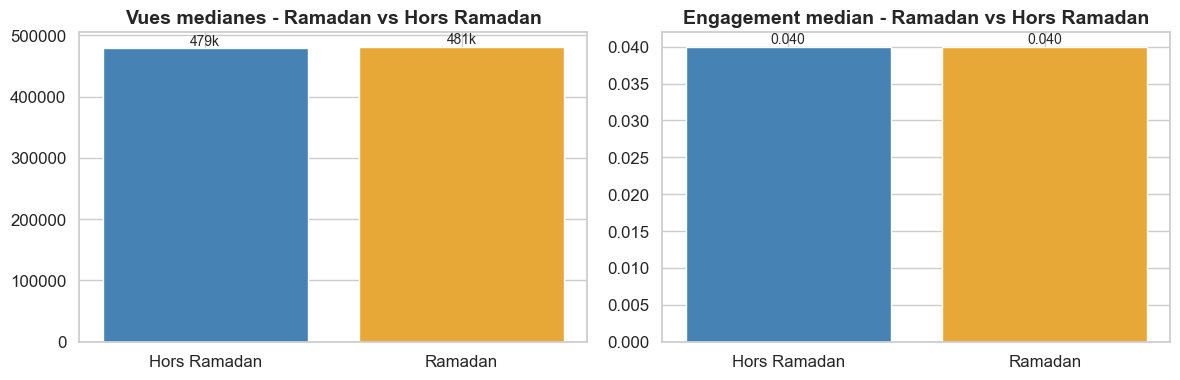

In [145]:
ramadan_comp = (
    df.groupby('is_ramadan')
    .agg(
        vues_medianes=('viewCount', 'median'),
        engagement_median=('engagement_rate', 'median'),
        nb_videos=('videoId', 'count')
    )
    .round(2)
)
ramadan_comp.index = ['Hors Ramadan', 'Ramadan']
ramadan_comp.columns = ['Vues medianes', 'Engagement median', 'Nb videos']
display(ramadan_comp)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, title in zip(
    axes,
    ['Vues medianes', 'Engagement median'],
    ['Vues medianes - Ramadan vs Hors Ramadan',
     'Engagement median - Ramadan vs Hors Ramadan']
):
    bars = ax.bar(ramadan_comp.index, ramadan_comp[col],
                  color=['steelblue', '#e8a838'])
    ax.set_title(title)
    for bar in bars:
        val = bar.get_height()
        label = "{:.3f}".format(val) if val < 1 else "{:.0f}k".format(val / 1e3)
        ax.text(bar.get_x() + bar.get_width() / 2,
                val * 1.01, label, ha='center', fontsize=10)

plt.tight_layout()
plt.show()


### 6.5 Analyse temporelle par theme

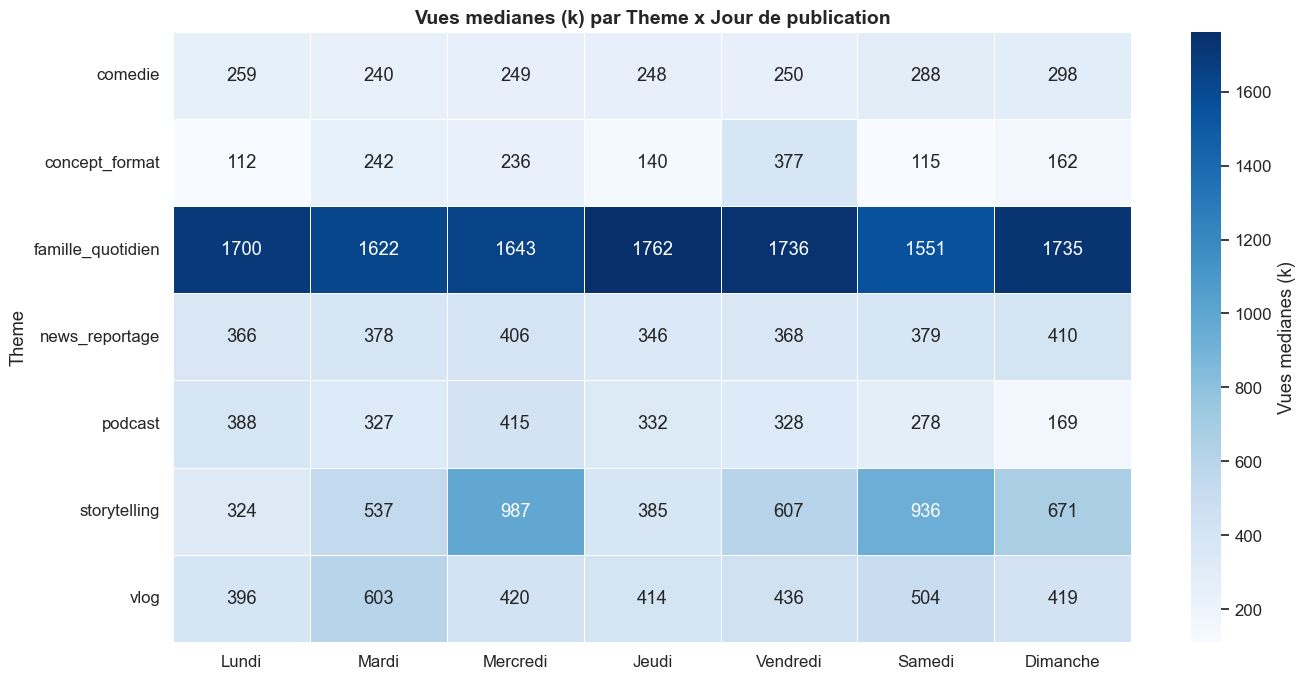

In [146]:
day_order = ['Lundi', 'Mardi', 'Mercredi', 'Jeudi', 'Vendredi', 'Samedi', 'Dimanche']
theme_time = df.groupby(['theme', 'day_name_fr'])['viewCount'].median().unstack()
theme_time = theme_time.reindex(columns=day_order)

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(theme_time / 1e3, annot=True, fmt='.0f', cmap='Blues',
            ax=ax, linewidths=0.5,
            cbar_kws={'label': 'Vues medianes (k)'})
ax.set_title("Vues medianes (k) par Theme x Jour de publication")
ax.set_xlabel("")
ax.set_ylabel("Theme")
plt.tight_layout()
plt.show()


## 7. Analyse par Youtubeur - Top 3 themes les plus populaires

### 7.1 Methodologie

Pour chaque createur, on decompose ses videos par `videoCategoryLabel` 
(la categorisation YouTube disponible dans les donnees) et on calcule 
la moyenne de vues par categorie. On retient le Top 3.

Cette analyse permet de voir sur quelle *sous-categorie de contenu* 
chaque createur performe le mieux, au-dela du theme editorial assigne.


In [147]:
# Top 3 categories (videoCategoryLabel) par createur avec moyenne de vues
results = []

for channel, group in df.groupby('channelTitle'):
    cat_stats = (
        group.groupby('videoCategoryLabel')
        .agg(
            avg_views=('viewCount', 'mean'),
            nb_videos=('videoId', 'count')
        )
        .query('nb_videos >= 3')   # au moins 3 videos pour etre significatif
        .sort_values('avg_views', ascending=False)
        .head(3)
        .reset_index()
    )
    for rank, row in enumerate(cat_stats.itertuples(), start=1):
        results.append({
            'Chaine'        : channel,
            'Theme_principal': df[df['channelTitle'] == channel]['theme'].iloc[0],
            'Rang'          : rank,
            'Categorie_YT'  : row.videoCategoryLabel,
            'Nb_videos'     : row.nb_videos,
            'Avg_views'     : round(row.avg_views)
        })

df_top3 = pd.DataFrame(results)
display(df_top3)


,Chaine,Theme_principal,Rang,Categorie_YT,Nb_videos,Avg_views
0,Abdelkader Kharraz,storytelling,1,People & Blogs,645,1075149
1,Ahmed Sabiri 2.0,comedie,1,Music,4,937288
2,Ahmed Sabiri 2.0,comedie,2,People & Blogs,159,410716
3,Amine Belghazi,concept_format,1,Entertainment,14,268863
4,Amine Belghazi,concept_format,2,People & Blogs,4,5140
5,B3A9Lii,comedie,1,People & Blogs,289,339191
6,BIMO,storytelling,1,Gaming,83,951906
7,BIMO,storytelling,2,Science & Technology,178,868034
8,BIMO,storytelling,3,Comedy,16,742647
9,Black Moussiba,comedie,1,Comedy,420,238821


### 7.2 Visualisation - Top categorie de chaque createur

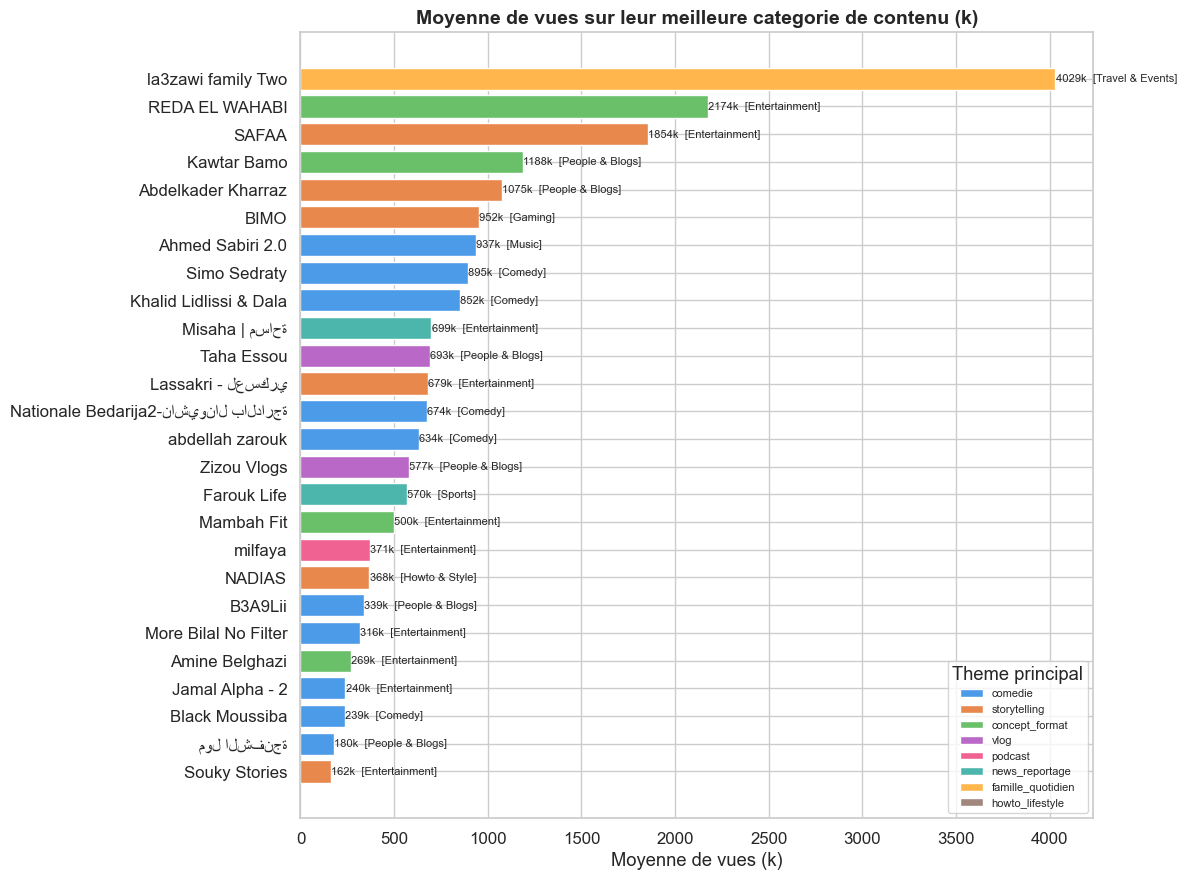

In [148]:
# Afficher uniquement le rang 1 (meilleure categorie) de chaque createur
df_rank1 = df_top3[df_top3['Rang'] == 1].sort_values('Avg_views', ascending=True)

fig, ax = plt.subplots(figsize=(12, 9))

# Couleur par theme principal
theme_colors = {
    'comedie'         : '#4C9BE8',
    'storytelling'    : '#E8884C',
    'concept_format'  : '#6ABF69',
    'vlog'            : '#BA68C8',
    'podcast'         : '#F06292',
    'news_reportage'  : '#4DB6AC',
    'famille_quotidien': '#FFB74D',
    'howto_lifestyle' : '#A1887F',
}
bar_colors = [theme_colors.get(t, 'gray') for t in df_rank1['Theme_principal']]

bars = ax.barh(df_rank1['Chaine'], df_rank1['Avg_views'] / 1e3, color=bar_colors)
ax.set_title("Moyenne de vues sur leur meilleure categorie de contenu (k)")
ax.set_xlabel("Moyenne de vues (k)")

for bar, row in zip(bars, df_rank1.itertuples()):
    ax.text(row.Avg_views / 1e3 + 1,
            bar.get_y() + bar.get_height() / 2,
            "{:.0f}k  [{}]".format(row.Avg_views / 1e3, row.Categorie_YT),
            va='center', fontsize=8)

# Legende themes
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=t) for t, c in theme_colors.items()]
ax.legend(handles=legend_elements, loc='lower right', fontsize=8, title="Theme principal")

plt.tight_layout()
plt.show()


### 7.3 Tableau detaille - Top 3 par createur

In [149]:
# Affichage propre createur par createur
for channel in sorted(df['channelTitle'].unique()):
    subset = df_top3[df_top3['Chaine'] == channel].copy()
    if subset.empty:
        continue
    theme_p = subset['Theme_principal'].iloc[0]
    print("=" * 55)
    print("  {} | Theme principal : {}".format(channel, theme_p))
    print("=" * 55)
    for _, row in subset.iterrows():
        print("  #{} {:25s}  {:>4} videos  {:>9,.0f} vues moy.".format(
            int(row['Rang']),
            row['Categorie_YT'],
            int(row['Nb_videos']),
            row['Avg_views']
        ))
    print()


  Abdelkader Kharraz | Theme principal : storytelling
  #1 People & Blogs              645 videos  1,075,149 vues moy.

  Ahmed Sabiri 2.0 | Theme principal : comedie
  #1 Music                         4 videos    937,288 vues moy.
  #2 People & Blogs              159 videos    410,716 vues moy.

  Amine Belghazi | Theme principal : concept_format
  #1 Entertainment                14 videos    268,863 vues moy.
  #2 People & Blogs                4 videos      5,140 vues moy.

  B3A9Lii | Theme principal : comedie
  #1 People & Blogs              289 videos    339,191 vues moy.

  BIMO | Theme principal : storytelling
  #1 Gaming                       83 videos    951,906 vues moy.
  #2 Science & Technology        178 videos    868,034 vues moy.
  #3 Comedy                       16 videos    742,647 vues moy.

  Black Moussiba | Theme principal : comedie
  #1 Comedy                      420 videos    238,821 vues moy.

  Farouk Life | Theme principal : news_reportage
  #1 Sports        

## 8. Synthese et Recommandations strategiques pour BIMO

In [150]:
# Resume automatique des insights cles
top3_themes = (
    df.groupby('theme')['viewCount']
    .median()
    .sort_values(ascending=False)
    .head(3)
)

best_day   = df.groupby('day_name_fr')['viewCount'].median().idxmax()
best_hour_utc = df.groupby('publish_hour')['viewCount'].median().idxmax()
best_hour_ma  = (best_hour_utc + 1) % 24
best_dur   = df.groupby('duration_category')['viewCount'].median().idxmax()

bimo_eng   = df[df['channelTitle'] == 'BIMO']['engagement_rate'].median()
global_eng = df['engagement_rate'].median()
delta      = (bimo_eng - global_eng) / global_eng * 100
sign       = '+' if delta > 0 else ''

print("=" * 60)
print("   SYNTHESE STRATEGIQUE - MARCHE YOUTUBE MAROCAIN")
print("=" * 60)
print()
print("Top 3 themes performants :")
for t, v in top3_themes.items():
    print("  -> {:<25} : {:.0f}k vues medianes".format(t, v / 1e3))

print()
print("Meilleur jour de publication     :", best_day)
print("Meilleure heure (heure Maroc)    : {}h00".format(best_hour_ma))
print("Format duree optimal             :", best_dur)
print()
print("Engagement rate BIMO             : {:.2f}%".format(bimo_eng * 100))
print("Engagement rate benchmark global : {:.2f}%".format(global_eng * 100))
print("BIMO est a {}{:.1f}% vs la mediane du benchmark".format(sign, delta))
print()
print("=" * 60)


   SYNTHESE STRATEGIQUE - MARCHE YOUTUBE MAROCAIN

Top 3 themes performants :
  -> famille_quotidien         : 1672k vues medianes
  -> storytelling              : 678k vues medianes
  -> vlog                      : 436k vues medianes

Meilleur jour de publication     : Mercredi
Meilleure heure (heure Maroc)    : 20h00
Format duree optimal             : Long (plus 20min)

Engagement rate BIMO             : 6.15%
Engagement rate benchmark global : 4.41%
BIMO est a +39.5% vs la mediane du benchmark



### 8.2 Interpretation et prochaines etapes

**Ce que ce notebook a etabli :**
- Les themes dominants en volume et en engagement sur le marche marocain
- Le positionnement reel de BIMO par rapport au benchmark des 26 createurs
- Les formats de duree et les creneaux temporels les plus performants
- L'effet Ramadan sur la consommation de contenu
- Le top 3 des categories de contenu les plus performantes pour chaque createur

**Prochaine etape - Notebook 2 :**
Analyse ultra-precise de la chaine BIMO via les donnees YouTube Studio
(watch time, CTR, retention, demographie audience, performances par video)
